In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [ ]:
iris_df = sns.load_dataset('iris')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris_df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
x = iris_df.drop('species', axis=1)
y = iris_df['species']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline(steps=[('baseline_model',DummyClassifier(strategy='most_frequent'))])

baseline_pipeline.fit(x_train,y_train)
y_pred_b = baseline_pipeline.predict(x_test)

print("Baseline Model Accuracy", (y_pred_b == y_test).mean())

Baseline Model Accuracy 0.3333333333333333


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

In [ ]:
tree_pipeline = Pipeline(
  steps = [
      ("tree_model", DecisionTreeClassifier(random_state=42))
  ]
)

tree_pipeline.fit(x_train,y_train)


Pipeline(steps=[('tree_model', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_pred = tree_pipeline.predict(x_test)

print("Decision Tree Model Accuracy", (y_pred== y_test).mean())

Decision Tree Model Accuracy 0.9333333333333333


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



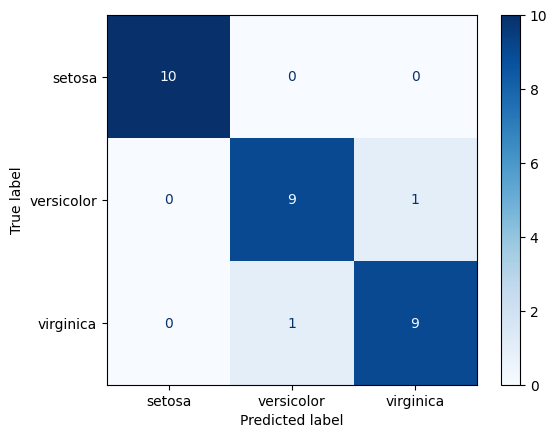

In [ ]:
cm = confusion_matrix(y_pred, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

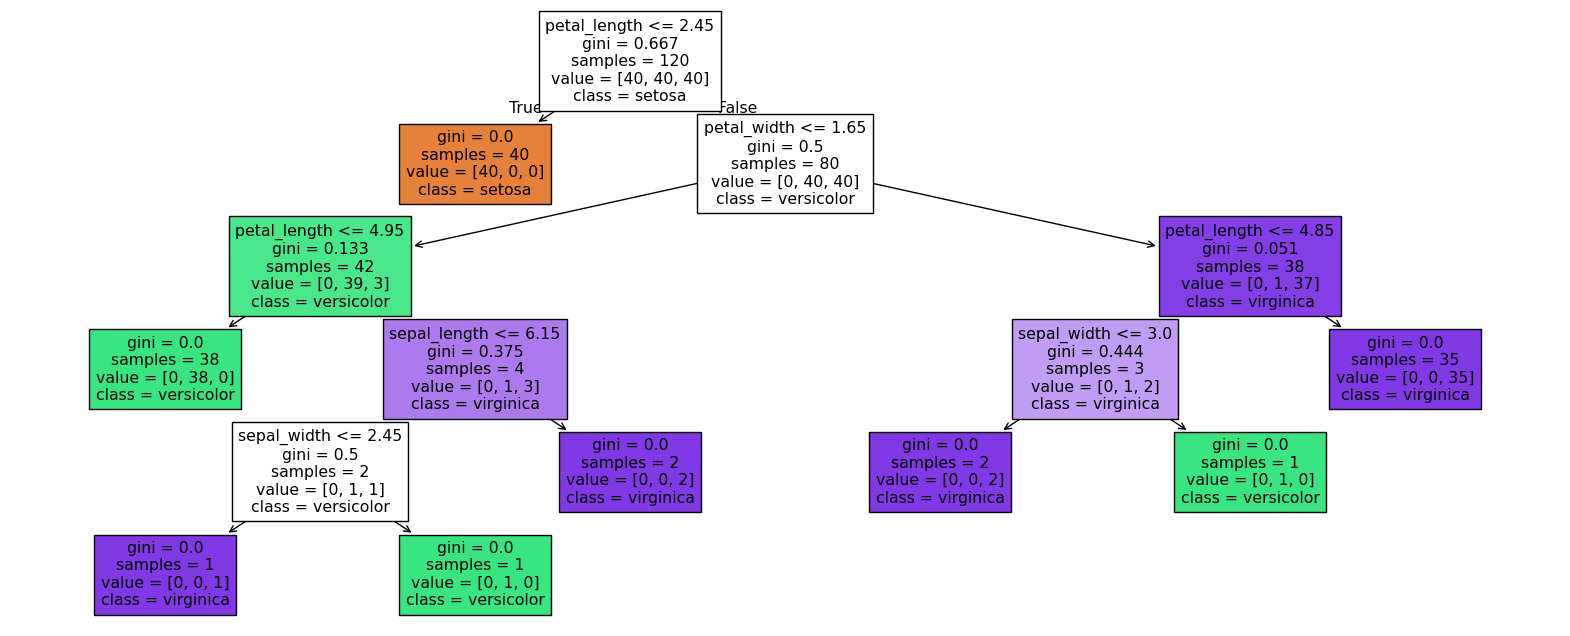

In [ ]:
plt.figure(figsize=(20,8))
plot_tree(tree_pipeline.named_steps["tree_model"],feature_names=x.columns, class_names=tree_pipeline.named_steps["tree_model"].classes_, filled=True)
plt.show()

In [ ]:
path = tree_pipeline.named_steps["tree_model"].cost_complexity_pruning_path(x_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00625    0.00811404 0.03392857 0.27067669 0.33333333]


In [ ]:
for a in ccp_alphas:
  tree_pipeline.named_steps["tree_model"].set_params(ccp_alpha =a)
  tree_pipeline.fit(x_train,y_train)
  y_pred = tree_pipeline.predict(x_test)

In [ ]:
print(f"Alpha: {a}, F1 Score: {f1_score(y_test,y_pred,average='macro')}")


Alpha: 0.3333333333333334, F1 Score: 0.16666666666666666


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)

alpha_f1_score=[]

for a in ccp_alphas:
  tree_pipeline.named_steps["tree_model"].set_params(ccp_alpha=a)
  f1_scores = cross_val_score(tree_pipeline, x_train, y_train, cv=cv, scoring='f1_macro')
  alpha_f1_score.append((a,f1_scores.mean()))

print(alpha_f1_score)

[(np.float64(0.0), np.float64(0.9496047307812013)), (np.float64(0.00625), np.float64(0.9496047307812013)), (np.float64(0.00811403508771929), np.float64(0.9579707438530967)), (np.float64(0.03392857142857145), np.float64(0.9327388733271086)), (np.float64(0.2706766917293233), np.float64(0.869081854964208)), (np.float64(0.3333333333333334), np.float64(0.16666666666666666))]


In [ ]:
best_alpha= max(alpha_f1_score, key=lambda x:x[1])[0]
print("Best Alpha:", best_alpha)


Best Alpha: 0.00811403508771929


In [ ]:
best_tree = DecisionTreeClassifier(random_state=42, criterion='gini', ccp_alpha=best_alpha)
best_tree.fit(x_train,y_train)
y_pred_best = best_tree.predict(x_test)

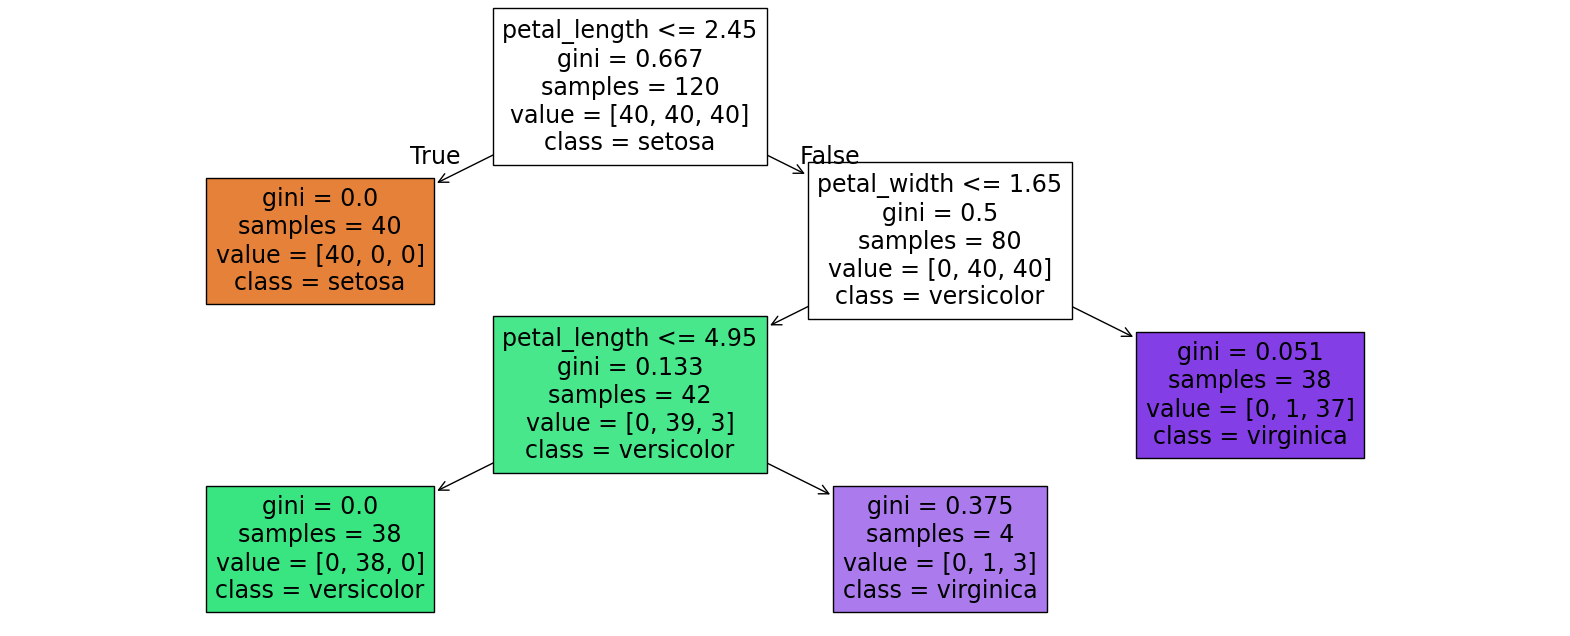

In [ ]:
plt.figure(figsize=(20,8))
plot_tree(best_tree,feature_names=x.columns, class_names=tree_pipeline.named_steps["tree_model"].classes_, filled=True)
plt.show()